Friday May 29th:
Basically, I wrote experiment code with functional decomp to make it more compact. Then I ran 5 experiments: 4 with 100 epochs and one with 200 epochs. I was testing whether mean or max pooling was better, and whether balancing the datasets in the BCE loss was helpful. 

The conclusions were slightly suprising. 

Firstly, I was able to reproduce Michael's initial results for the control (100 epochs on mean pooling), and even got slightly higher accuracies. Additionally, I found that balancing through the BCE weights matrix doesn't seem to be too effective - it seemed to only slightly affect the accuracies, but the loss was much higher in all cases. More data analysis should be conducted though to see if there is a significant difference.

The second conclusion was that mean pooling is far better than max pooling, improving the accuracy by ~10%. The loss graphs are also much smoother.

Lastly, training for 200 epochs didn't seem to be too helpful.

Sat May 30th:
Michael and I added a baseline random labels experiment, and we also graphed the data from the first few experiments. I also manually implemented weighted BCE loss and found that it was pretty consistent with the built-in method for manual BCE loss. Lastly, I implemented focal loss relatively quickly, but I am unsure if the implementation was correct or if the parameters were optimal -- this needs more investigation.

Sun May 30th:
Michael added the pi charts and we discussed possible changes to the model, in particular, Michael researched the use of concatenating with another foundation model, but we decided against it.

In [41]:
import numpy as np
import pandas as pd
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# #for google colab only
# !pip install fair-esm

In [2]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/df_train_loc_mean.csv")
train_df_max = pd.read_csv("../processed_data/df_train_loc_max.csv")

In [10]:
locations = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

LOCATIONS = locations

# mean
y_train_df_mean = train_df_mean[locations]
balancing_weights = y_train_df_mean.shape[0]/y_train_df_mean.sum(axis=0)
# make the x_train_df_mean - could use a list comprehension or use the pandas series functions
# however, its more efficient to make a boolean array
selected_cols_mean = train_df_mean.columns[train_df_mean.columns.str.startswith('emb_')]
x_train_df_mean = train_df_mean.loc[:, selected_cols_mean]

# max
y_train_df_max = train_df_max[locations]
selected_cols_max = train_df_max.columns[train_df_max.columns.str.startswith('emb_')]
x_train_df_max = train_df_max.loc[:, selected_cols_max]

In [42]:
# generate train/dev split - classic 80/20 split with random set to a seed for comparability
from sklearn.model_selection import train_test_split

# for mean
x_train_mean, x_dev_mean, y_train_mean, y_dev_mean = train_test_split(x_train_df_mean, y_train_df_mean, test_size=0.2, random_state=42)

# for max
x_train_max, x_dev_max, y_train_max, y_dev_max = train_test_split(x_train_df_max, y_train_df_max, test_size=0.2, random_state=42)

In [43]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# load the batches and make the model for mean
x_train_mean_tensor = torch.tensor(x_train_mean.values, dtype=torch.float32) # 32 is standard for pytorch
y_train_mean_tensor = torch.tensor(y_train_mean.values, dtype=torch.float32)
train_dataset_mean = TensorDataset(x_train_mean_tensor, y_train_mean_tensor)
train_loader_mean = DataLoader(train_dataset_mean, batch_size=64, shuffle=True)

# load the batches and make the model for max
x_train_max_tensor = torch.tensor(x_train_max.values, dtype=torch.float32)
y_train_max_tensor = torch.tensor(y_train_max.values, dtype=torch.float32)
train_dataset_max = TensorDataset(x_train_max_tensor, y_train_max_tensor)
train_loader_max = DataLoader(train_dataset_max, batch_size=64, shuffle=True)

# make dev tensors
x_dev_mean_tensor = torch.tensor(x_dev_mean.values, dtype=torch.float32)
y_dev_mean_tensor = torch.tensor(y_dev_mean.values, dtype=torch.float32)
x_dev_max_tensor = torch.tensor(x_dev_max.values, dtype=torch.float32)
y_dev_max_tensor = torch.tensor(y_dev_max.values, dtype=torch.float32)

In [44]:
# make the model - single linear layer - logistic regression with BCE loss

class LogisticRegression(nn.Module):
    
    def __init__(self, input_size, num_logits):
        # call to the __init__ function of the super class
        super().__init__()

        # Bookkeeping: Sacing the initialization parameters
        self.input_size = input_size
        self.num_logits = num_logits

        # Defining the model
        self.model = nn.Sequential(
            nn.Linear(self.input_size, self.num_logits)
        )

    def forward(self, x):
        logits = self.model(x)
        return logits
    

In [45]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model
def train_model(model, loader, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    # initialize the lists
    print("Training started!")
    train_loss_lst = []
    dev_loss_lst = []
    # go through the training epochs
    for epoch in range(num_epochs):
        train_loss = 0.0
        # configure the model for training
        model.train()
        for batch in loader:
            inputs, labels = batch
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)
        
        # evaluate the dev set
        model.eval()
        with torch.no_grad():
            logits_dev = model(x_dev_tensor)
            loss_dev = criterion(logits_dev, y_dev_tensor)
            dev_loss_lst.append(loss_dev.item())
        # print the progress
        #if epoch % 10 == 0 or epoch == num_epochs - 1:
            #print(f"Epoch {epoch+1}/{num_epochs}, Train Loss {train_loss:.4f}, Dev Loss {loss_dev.item():.4f}")
    print("Training Complete!")
    return train_loss_lst, dev_loss_lst

def plot_losses(train_loss_lst, dev_loss_lst, n_epochs, experiment_title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_loss_lst, label='train')
    plt.plot(range(1, n_epochs + 1), dev_loss_lst,   label='dev')
    plt.xlabel('Epoch')
    plt.ylabel('Avg BCE Loss')
    plt.title(f"Training vs. Dev Loss for {experiment_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

def run_experiment(x_train, y_train, train_loader, x_dev, y_dev, criterion, experiment_title, num_epochs):
    model = LogisticRegression(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_model(model, train_loader, criterion, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    #plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

# all thresholds set to 0.5
def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    model_accs = [acc_exact, jaccard, micro_f1, macro_f1]
    
    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {class_acc:>10.4f} {class_mcc:>10.4f}")
    return model_accs, class_mccs


In [46]:
# play with tuning the decision boundaries

# computes the accuracy (MCC) for a specific location given a specific cutoff and returns that accuracy
def compute_adjusted_accuracy_on_loc(model, X_dev, Y_dev, cutoff, location):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(X_dev))[:,location]
        pred = (prob > cutoff).float()

    y_np = Y_dev[:,location].numpy().astype(int)
    p_np = pred.numpy().astype(int)

    class_mcc = matthews_corrcoef(y_np, p_np)
    return class_mcc

# takes in a list of cutoffs and locations, as well as a model and the dev sets,
# and returns a dictionary of Key: location index , value: cutoff value
def compute_optimized_cutoffs(model, X_dev, Y_dev, locations):
    cutoffs = np.arange(0.01, 1.00, 0.01, dtype=float)
    cutoff_dict = {}
    for location in range(len(locations)):
        best_cutoff = 0.00
        best_mcc = 0.00
        for cutoff in cutoffs:
            this_mcc = compute_adjusted_accuracy_on_loc(model, X_dev, Y_dev, cutoff, location)
            if this_mcc > best_mcc:
                best_mcc = this_mcc
                best_cutoff = cutoff
        print(f"{locations[location]:<25}, Best Cutoff: {best_cutoff:>10.4f}, Best MCC: {best_mcc:>10.4f}")
        cutoff_dict[location] = best_cutoff
    return cutoff_dict

# same compute accuracy function but it uses the optimized cutoff for each class
def compute_accuracy_with_special_cutoffs(model, X_dev, Y_dev, locations, cutoffs_dict):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = probs
        for location in range(len(locations)):
            cutoff = cutoffs_dict[location]
            preds[:,location] = (preds[:,location] > cutoff).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    class_accs = [acc_exact, jaccard, micro_f1, macro_f1]

    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC (adapted from deeploc2 per-class MCC loop)
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {cls_acc:>10.4f} {cls_mcc:>10.4f}")
    return class_accs, class_mccs

In [ ]:
# experiment 1: no reweighting on mean - 100 epochs
def exp1():
    criterion_1 = nn.BCEWithLogitsLoss()
    reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp1()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_1 = np.mean(accs_np, axis=0)
std_accs_1 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_1 = np.mean(mccs_np, axis=0)
std_mccs_1 = np.std(mccs_np, ddof=1, axis=0)
print(mean_accs_1)
print(std_accs_1)
print(mean_mccs_1)
print(std_mccs_1)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.
[0.51542289 0.67718529 0.7366746  0.63087558]
[0.00358419 0.00270755 0.00174731 0.00440404]
[0.71867612 0.59314641 0.64827544 0.8599905  0.65979083 0.70704874
 0.85307096 0.49853049 0.2552868  0.48334756 0.43144097]
[5.26920009e-03 3.89250324e-03 3.60460172e-03 6.98517081e-03
 2.48987878e-03 2.55311304e-03 1.19609982e-02 1.59230486e-02
 1.42288615e-02 1.90429006e-02 6.20633538e-17]


In [19]:
# experiment 2: no reweighting on max - 100 epochs
def exp2():
    criterion_2 = nn.BCEWithLogitsLoss()
    reg_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_2, experiment_title="Max Embeddings no Weights - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy(reg_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp2()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_2 = np.mean(accs_np, axis=0)
std_accs_2 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_2 = np.mean(mccs_np, axis=0)
std_mccs_2 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [20]:
# experiment 3: reweighting on mean - 100 epochs
def exp3():
    criterion_3 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
    reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_3,  experiment_title="Mean Embeddings with Weights - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp3()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_3 = np.mean(accs_np, axis=0)
std_accs_3 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_3 = np.mean(mccs_np, axis=0)
std_mccs_3 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [21]:
# experiment 4: reweighting on max - 100 epochs
def exp4():
    criterion_4 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
    reweighting_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_4, experiment_title="Max Embeddings with Weights - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy(reweighting_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp4()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_4 = np.mean(accs_np, axis=0)
std_accs_4 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_4 = np.mean(mccs_np, axis=0)
std_mccs_4 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [22]:
# experiment 5: no reweighting on mean - 200 epochs
def exp5():
    criterion_5 = nn.BCEWithLogitsLoss()
    reg_model_mean_200 = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_5, experiment_title="Mean Embeddings no Weights - 200 Epochs", num_epochs=200)
    accs, mccs = compute_accuracy(reg_model_mean_200, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp5()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_5 = np.mean(accs_np, axis=0)
std_accs_5 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_5 = np.mean(mccs_np, axis=0)
std_mccs_5 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [23]:
# experiment 6: pos-reweighting (different than regular reweighting) on mean - 100 epochs
def exp6():
    criterion_6 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
    pos_reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_6,  experiment_title="Mean Embeddings with Pos-Weights - 100 Epochs", num_epochs=100)
    acc, mcc = compute_accuracy(pos_reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    return acc, mcc

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp6()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_6 = np.mean(accs_np, axis=0)
std_accs_6 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_6 = np.mean(mccs_np, axis=0)
std_mccs_6 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [24]:
# experiment 7: baseline nonsense data

# make nonsense data by shuffling the labels
y_dev_mean_tensor_shuffled = y_dev_mean_tensor[torch.randperm(y_dev_mean_tensor.size(0))]

# compute accuracy of the original model on the shuffled labels as a sanity check - should be very low

def exp7():
    criterion_1 = nn.BCEWithLogitsLoss()
    reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights, CNTRL - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor_shuffled, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp7()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_7 = np.mean(accs_np, axis=0)
std_accs_7 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_7 = np.mean(mccs_np, axis=0)
std_mccs_7 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [ ]:
# experiment 8: investigate the shape of the weights for the positive examples and BCE loss
balancing_weights_matrix = np.diag(np.array(y_train_df_mean.shape[0]/y_train_df_mean.sum(), dtype=np.float32))

# does this help the accuracy? make custom loss instead of BCEWithLogitsLoss
def custom_bce_loss(logits, y_train):
    sigmoid = torch.sigmoid(logits)
    sigmoid = torch.clamp(sigmoid, 1e-7, 1-1e-7) # to avoid log(0)
    L1 = torch.log(sigmoid)-torch.log(1-sigmoid)
    L0 = torch.ones((sigmoid.shape[1], sigmoid.shape[0]), device=logits.device) @ torch.log(1-sigmoid)
    loss_matrix = (y_train.T @ L1 + L0)
    normalization = 1/(sigmoid.shape[0]*sigmoid.shape[1])
    y = -normalization*torch.trace(loss_matrix)
    return y

# now make the custom los weighted and see if it helps the accuracy
def custom_weighted_bce_loss(logits, y_train):
    sigmoid = torch.sigmoid(logits)
    sigmoid = torch.clamp(sigmoid, 1e-7, 1-1e-7) # to avoid log(0)
    L1 = torch.log(sigmoid)-torch.log(1-sigmoid)
    L0 = torch.ones((sigmoid.shape[1], sigmoid.shape[0]), device=logits.device) @ torch.log(1-sigmoid)
    loss_matrix = (y_train.T @ L1 + L0)
    loss_matrix_weighted = loss_matrix @ torch.tensor(balancing_weights_matrix, device=logits.device)
    normalization = 1/(sigmoid.shape[0]*sigmoid.shape[1])
    y = -normalization*torch.trace(loss_matrix_weighted)
    return y

criterion_8_unweighted = custom_bce_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_8_unweighted,  experiment_title="Mean Embeddings with no Weights, custom BCE loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

criterion_8_weighted = custom_weighted_bce_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_8_weighted,  experiment_title="Mean Embeddings with Weights, custom BCE loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)


In [25]:
# experiment 9: investigate focal loss - mean - 100 epochs
import torchvision

def focal_loss(logits, y_train):
    return torchvision.ops.sigmoid_focal_loss(logits, y_train, reduction='mean')

def exp9():
    criterion_9 = focal_loss
    reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_9,  experiment_title="Mean Embeddings with focal loss", num_epochs=100)
    accs, mccs = compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp9()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_9 = np.mean(accs_np, axis=0)
std_accs_9 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_9 = np.mean(mccs_np, axis=0)
std_mccs_9 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.


In [26]:
# experiment 10: play with tuning the decision boundaries
# train control with no reweighting on mean - 100 epochs
def exp10():
    criterion_1 = nn.BCEWithLogitsLoss()
    reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
    best_cutoffs = compute_optimized_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    accs, mccs = compute_accuracy_with_special_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations, best_cutoffs)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp10()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_10 = np.mean(accs_np, axis=0)
std_accs_10 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_10 = np.mean(mccs_np, axis=0)
std_mccs_10 = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training started!
Training Complete!
Membrane                 , Best Cutoff:     0.4800, Best MCC:     0.7244
Cytoplasm                , Best Cutoff:     0.3700, Best MCC:     0.6156
Nucleus                  , Best Cutoff:     0.5500, Best MCC:     0.6594
Extracellular            , Best Cutoff:     0.3600, Best MCC:     0.8898
Cell membrane            , Best Cutoff:     0.3500, Best MCC:     0.6771
Mitochondrion            , Best Cutoff:     0.4600, Best MCC:     0.7144
Plastid                  , Best Cutoff:     0.3300, Best MCC:     0.8765
Endoplasmic reticulum    , Best Cutoff:     0.5000, Best MCC:     0.5226
Lysosome/Vacuole         , Best Cutoff:     0.2300, Best MCC:     0.3887
Golgi apparatus          , Best Cutoff:     0.3000, Best MCC:     0.5955
Peroxisome               , Best Cutoff:     0.3900, Best MCC:     0.5878
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Membrane                 , Best Cutoff:     0.4600, Best MCC:     0.723

In [36]:
from great_tables import GT

# visualize each model in a table
metrics_acc = ['Exact Acc.', 'Jaccard', 'Micro F1', 'Macro F1']
metrics_mcc = ['Membrane MCC', 'Cytoplasm MCC', 'Nucleus MCC', 'Extracellular MCC', 'Cell membrane MCC',
             'Mitochondrion MCC', 'Plastid MCC', 'Endoplasmic reticulum MCC', 'Lysosome/Vacuole MCC',
             'Golgi apparatus MCC', 'Peroxisome MCC']

# control mean
mean_accs_7
std_accs_7
mean_mccs_7
std_mccs_7
# mean
mean_accs_1
std_accs_1
mean_mccs_1
std_mccs_1
# mean reweighting
mean_accs_3
std_accs_3
mean_mccs_3
std_mccs_3
# max
mean_accs_2
std_accs_2
mean_mccs_2
std_mccs_2
# max reweighting
mean_accs_4
std_accs_4
mean_mccs_4
std_mccs_4
# mean mcc correction
mean_accs_10
std_accs_10
mean_mccs_10
std_mccs_10

model_names_t1 = ["Random Control", "Mean", "Mean Reweighted", "Mean ROC Adjustment"]
model_names_t2 = ["Mean", "Max", "Mean Reweighted", "Max Reweighted"]
model_names_t3 = ["Random Control", "Mean", "Mean Reweighted", "Mean ROC Adjustment"]

all_means_t1 = np.column_stack([mean_accs_7, mean_accs_1, mean_accs_3, mean_accs_10])
all_stds_t1 = np.column_stack([std_accs_7, std_accs_1, std_accs_3, std_accs_10])

all_means_t2 = np.column_stack([mean_accs_1, mean_accs_2, mean_accs_3, mean_accs_4])
all_stds_t2 = np.column_stack([std_accs_1, std_accs_2, std_accs_3, std_accs_4])

all_means_t3 = np.column_stack([mean_mccs_7, mean_mccs_1, mean_mccs_3, mean_mccs_10])
all_stds_t3 = np.column_stack([std_mccs_7, std_mccs_1, std_mccs_3, std_mccs_10])

rows_t1 = []
rows_t2 = []
rows_t3 = []
for i, metric in enumerate(metrics_acc):
    row_t1 = {"Metric": metric}
    row_t2 = {"Metric": metric}
    row_t3 = {"Metric": metric}
    for j, model_name in enumerate(model_names_t1):
        mean_val = all_means_t1[i,j]
        std_val = all_stds_t1[i,j]
        cell_string = f"{mean_val:.2f} ± {std_val:.2f}"
        row_t1[model_name] = cell_string
    rows_t1.append(row_t1)
    for j, model_name in enumerate(model_names_t2):
        mean_val = all_means_t2[i,j]
        std_val = all_stds_t2[i,j]
        cell_string = f"{mean_val:.2f} ± {std_val:.2f}"
        row_t2[model_name] = cell_string
    rows_t2.append(row_t2)
for i, metric in enumerate(metrics_mcc):
    row_t3 = {"Metric": metric}
    for j, model_name in enumerate(model_names_t3):
        mean_val = all_means_t3[i,j]
        std_val = all_stds_t3[i,j]
        cell_string = f"{mean_val:.2f} ± {std_val:.2f}"
        row_t3[model_name] = cell_string
    rows_t3.append(row_t3)

df_t1 = pd.DataFrame(rows_t1)
df_t2 = pd.DataFrame(rows_t2)
df_t3 = pd.DataFrame(rows_t3)

def style_table(df, model_names, title):
    return (
        GT(df, rowname_col="Metric")
        .tab_header(title=title)
        .fmt_markdown(columns=model_names)
        .tab_options(
            table_font_names="system-ui, -apple-system, sans-serif",
            table_background_color="#ffffff",
            heading_align="left",
            heading_title_font_size="13pt",
            heading_title_font_weight="bold",
            column_labels_background_color="#f8fafc",
            column_labels_font_weight="600",
            column_labels_border_top_style="solid",
            column_labels_border_top_width="2px",
            column_labels_border_top_color="#cbd5e1",
            column_labels_border_bottom_style="solid",
            column_labels_border_bottom_width="2px",
            column_labels_border_bottom_color="#cbd5e1",
            row_group_background_color="#f1f5f9",
            row_group_font_weight="bold",
            row_group_font_size="10pt",
            table_border_bottom_style="solid",
            table_border_bottom_width="2px",
            table_border_bottom_color="#94a3b8",
            data_row_padding="7px"
        )
    )

gt_table_1 = style_table(df_t1, model_names_t1, "Table 1: Mean Pooling vs. ROC Adjustments")
gt_table_2 = style_table(df_t2, model_names_t2, "Table 2: Mean Pooling vs. Max Pooling Strategies")
gt_table_3 = style_table(df_t3, model_names_t3, "Table 1: Mean Pooling vs. ROC Adjustments MCCs")

# save them
gt_table_1.save("table_1_pooling_vs_roc.pdf")
gt_table_2.save("table_2_pooling_vs_max.pdf")
gt_table_3.save("table_3_pooling_vs_max.pdf")

GT(_tbl_data=                       Metric Random Control         Mean Mean Reweighted  \
0                Membrane MCC    0.02 ± 0.00  0.72 ± 0.01     0.71 ± 0.00   
1               Cytoplasm MCC    0.02 ± 0.00  0.59 ± 0.00     0.59 ± 0.00   
2                 Nucleus MCC    0.02 ± 0.00  0.65 ± 0.00     0.65 ± 0.00   
3           Extracellular MCC   -0.02 ± 0.00  0.86 ± 0.01     0.86 ± 0.01   
4           Cell membrane MCC    0.06 ± 0.00  0.66 ± 0.00     0.66 ± 0.00   
5           Mitochondrion MCC    0.00 ± 0.00  0.71 ± 0.00     0.71 ± 0.00   
6                 Plastid MCC   -0.01 ± 0.00  0.85 ± 0.01     0.86 ± 0.01   
7   Endoplasmic reticulum MCC   -0.02 ± 0.00  0.50 ± 0.02     0.51 ± 0.01   
8        Lysosome/Vacuole MCC   -0.02 ± 0.00  0.26 ± 0.01     0.25 ± 0.01   
9         Golgi apparatus MCC    0.04 ± 0.00  0.48 ± 0.02     0.49 ± 0.03   
10             Peroxisome MCC   -0.00 ± 0.00  0.43 ± 0.00     0.43 ± 0.00   

   Mean ROC Adjustment  
0          0.72 ± 0.00  
1          0.62 ± 0.00  
2          0.66 ± 0.00  
3          0.89 ± 0.00  
4          0.68 ± 0.00  
5          0.72 ± 0.00  
6          0.88 ± 0.00  
7          0.52 ± 0.00  
8          0.39 ± 0.00  
9          0.58 ± 0.01  
10         0.59 ± 0.00  , _body=<great_tables._gt_data.Body object at 0x164b43020>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.stub: 2>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Random Control', type=<ColInfoTypeEnum.default: 1>, column_label='Random Control', column_align='left', column_width=None), ColInfo(var='Mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='left', column_width=None), ColInfo(var='Mean Reweighted', type=<ColInfoTypeEnum.default: 1>, column_label='Mean Reweighted', column_align='left', column_width=None), ColInfo(var='Mean ROC Adjustment', type=<ColInfoTypeEnum.default: 1>, column_label='Mean ROC Adjustment', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x164bc5640>, _spanners=Spanners([]), _heading=Heading(title='Table 1: Mean Pooling vs. ROC Adjustments MCCs', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x165cc4770>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x165cc4710>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x164bc54a0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x164bc5230>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#ffffff'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['system-ui, -apple-system, sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), ta

In [ ]:
# visualize the initial experiments with a bar graph of the exact match accuracy, hamming accuracy, jaccard score, micro F1, and macro F1 for each experiment

# 5 lists, each one for each experiment, containing the 5 metrics in order: exact match accuracy, hamming accuracy, jaccard score, micro F1, and macro F1
exp_1_means = [] # control
exp_1_data = [] # mean, no weights, 100 epochs
exp_3_data = [] # mean, weights, 100 epochs
exp_2_data = [] # max, no weights, 100 epochs
exp_4_data = [] # max, weights, 100 epochs
metrics = ['Exact Match Accuracy', 'Jaccard Score', 'Micro F1', 'Macro F1']
experiments = ['Mean, No Weights, Shuffled Dev Labels', 'Mean, No Weights, 100 Epochs', 'Max, No Weights, 100 Epochs', 'Mean, Weights, 100 Epochs', 'Max, Weights, 100 Epochs']

# make the bar plot of mean vs. shuffled for the 5 metrics
x = np.arange(len(metrics))
width = 0.15
plt.figure(figsize=(12, 6))
plt.bar(x - 2*width, exp_7_data, width, label=experiments[0], color='blue', alpha=0.3)
plt.bar(x - width, exp_1_data, width, label=experiments[1], color='blue', alpha=0.6)
plt.bar(x, exp_3_data, width, label=experiments[3], color='blue', alpha=0.9)
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Comparison of Experiments on Dev Set (Mean Pooling)')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# make the bar plot of mean vs. max for the 5 metrics
x = np.arange(len(metrics))
width = 0.15
plt.figure(figsize=(12, 6))
plt.bar(x - width, exp_1_data, width, label=experiments[1], color='blue', alpha=0.6)
plt.bar(x, exp_2_data, width, label=experiments[2], color='blue')
plt.bar(x + width, exp_3_data, width, label=experiments[3], color='red', alpha=0.6)
plt.bar(x + 2*width, exp_4_data, width, label=experiments[4], color='red')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Comparison of Experiments on Dev Set')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def plot_prediction_pies(truth_data, predicted_data, graph_name):
    diff = truth_data - predicted_data  # (2211, 11)

    has_pos = (diff ==  1).any(dim=1)  # underpredicted at least one label
    has_neg = (diff == -1).any(dim=1)  # overpredicted at least one label

    exact = (~has_pos & ~has_neg).sum().item()
    underpredict = ( has_pos & ~has_neg).sum().item()
    overpredict = (~has_pos &  has_neg).sum().item()
    both = ( has_pos &  has_neg).sum().item()

    labels = ['Exact match', 'Underprediction', 'Overprediction', 'Wrong both directions']
    sizes = [exact, underpredict, overpredict, both]

    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Prediction error categories for {graph_name}')
    plt.show()


    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(18, 7))
    axes = axes.flatten()

    labels = ['TP', 'FN', 'FP'] #truth, missed, false prediction
    colors = ["#5590D9", "#FF8C00", "#D94040"]

    for i, loc in enumerate(LOCATIONS):
        t = truth_data[:, i]
        p = predicted_data[:, i]

        tp = ((t == 1) & (p == 1)).sum().item()
        fn = ((t == 1) & (p == 0)).sum().item()
        fp = ((t == 0) & (p == 1)).sum().item()

        sizes = [tp, fn, fp]
        axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[i].set_title(f"{loc} \n n = { tp+fn+fp} ", fontsize=15)

    axes[-1].set_visible(False)
    fig.suptitle(f'TP / FN / FP breakdown per location for {graph_name}', fontsize=25)
    plt.tight_layout()
    plt.show()

In [39]:
#exp1 prediction pies
criterion_1 = nn.BCEWithLogitsLoss()
reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
accs, mccs = compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Training started!
Training Complete!


tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.]])


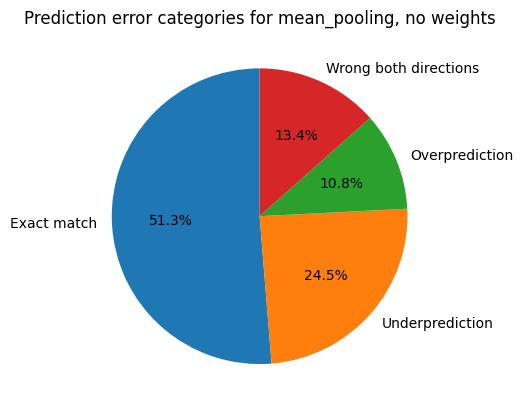

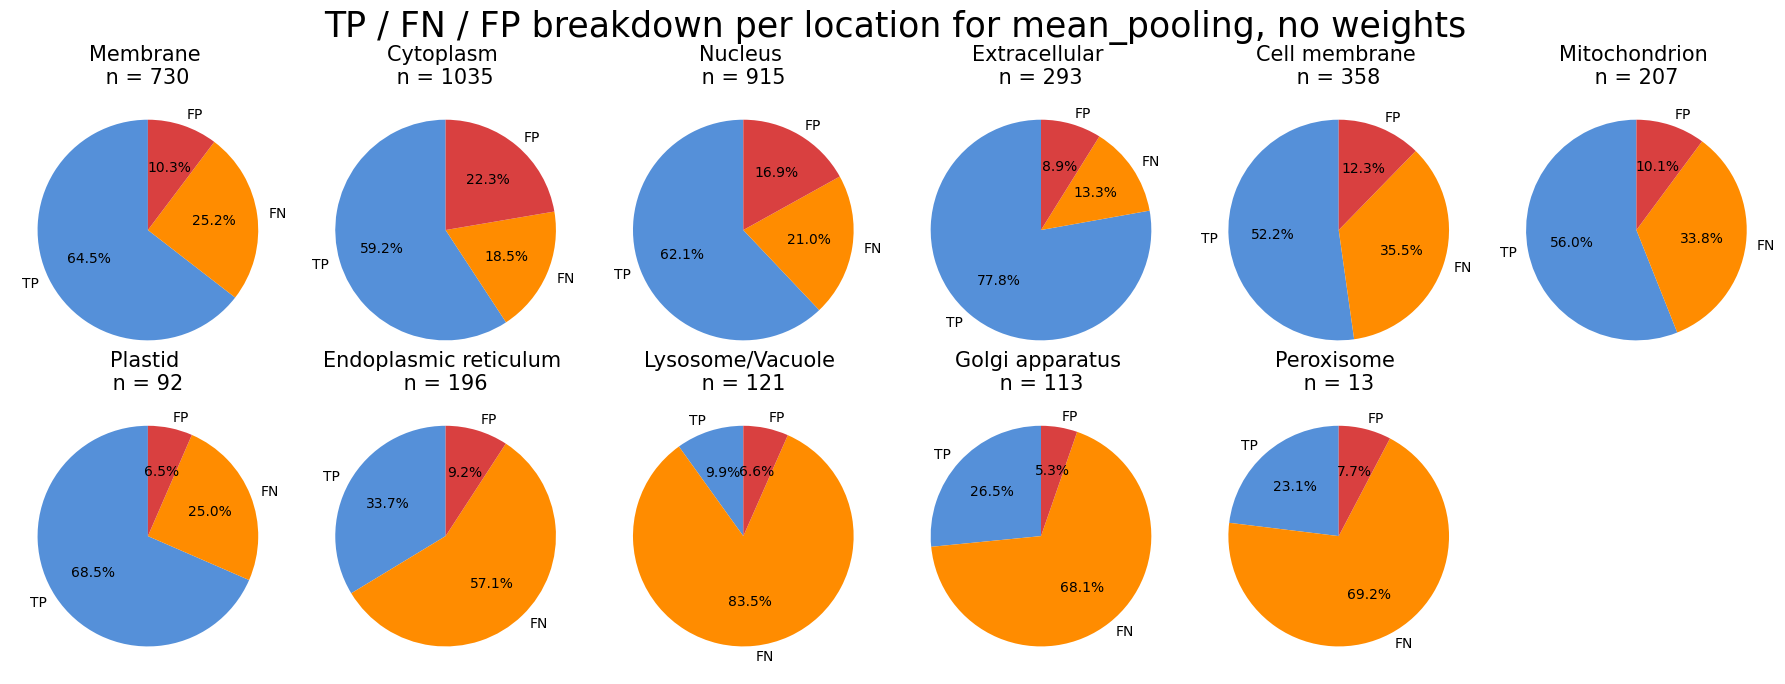

In [40]:
reg_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds = (probs > 0.5).float()
print(preds)

reg_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds_mean_pooling = (probs > 0.5).float()
graph_name = "mean_pooling, no weights"
plot_prediction_pies(y_dev_mean_tensor, preds_mean_pooling, graph_name)

In [ ]:
# redo the pie charts model
graph_name = "mean_pooling, no weights"
reg_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds = probs
    for location in range(len(locations)):
        cutoff = best_cutoffs[location]
        preds[:,location] = (preds[:,location] > cutoff).float()
sums = preds.sum(axis=0)
sums_dev = y_dev_mean_tensor.sum(axis=0)
for i in range(sums.shape[0]):
    location = locations[i]
    print(f"{location}: {sums[i]-sums_dev[i]}")
    print()
print(sums.sum()-sums_dev.sum())
print(sums_dev.sum())
print(sums.sum()/sums_dev.sum()*100)
plot_prediction_pies(y_dev_mean_tensor, preds, graph_name)
plot_prediction_pies(y_dev_mean_tensor, preds, graph_name)

In [ ]:
reweighting_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds_mean_weight_pooling = (probs > 0.5).float()
graph_name = "mean_pooling, reweighted"
plot_prediction_pies(y_dev_mean_tensor, preds_mean_weight_pooling, graph_name)